# Demo: Full Pipeline

This notebook demonstrates, end-to-end, how we **modify a baseline projected life table** to account for **changes in temperature exposure under climate scenarios**.

**Core idea:** climate change is introduced via an **age- and year-specific multiplicative adjustment** to baseline all-cause mortality.

Pipeline (high level):

1. Load baseline mortality projections (reference life table, no explicit climate effect).
2. Load temperature distributions (historical baseline + projected under an RCP).
3. Load temperature–mortality **relative risk (RR) curves** by age (Exposure-Response Functions).
4. Compute annual mean RR by age/year from the temperature histogram.
5. Normalize to a historical reference period to obtain a **mortality multiplier**.
6. Apply the multiplier to baseline mortality rates → climate-adjusted life table.
7. Compute cohort EPVs for annuities and life insurance under reference vs climate-adjusted mortality.
8. (Optional) propagate uncertainty via Monte Carlo (RR parameters + climate model ensemble + adaptation scenarios).

## Inputs used in the demo

This demo assumes you have already exported a ZIP (e.g. `results_csv.zip`) containing:

**Temperature**
- `temp_distribution_baseline_<city>.csv` (baseline histogram; used for knots/bounds and normalization baseline)
- `temp_distribution_projection_<city>.csv` (projected histograms by year under multiple RCPs)

**Epidemiology (RR curves)**
- `coefs_<city>.csv` containing spline coefficients (e.g. `b1..bK`) by city code and age group

**Actuarial baseline**
- `<city>_mortality_projections.csv` with baseline projected mortality by age/year (e.g. Eurostat-based)

In the code cells, we set:
- `city_name` $\in$ `{Bucharest, Helsinki, Rome}`
- `rcp` $\in$ `{2.6, 4.5, 7.0}`

---

## 0. Imports and Mount Drive

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import pyarrow.dataset as ds
import re

from patsy import dmatrix
from typing import Sequence, Tuple, Optional, List, Union

from google.colab import files
import zipfile
import os


In [3]:
print("Please upload the file: results_csv.zip")
uploaded = files.upload()

# Extract zip
zip_filename = "results_csv.zip"
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(".")

print("Unzipped contents:")
print(os.listdir("results_csv"))

BASE = Path("results_csv")

Please upload the file: results_csv.zip


Saving results_csv.zip to results_csv.zip
Unzipped contents:
['mortality_multipliers_cohort_bucharest.csv', 'mortality_multiplier_by_rcp_combined_bucharest.csv', 'mortality_multiplier_by_rcp_combined_helsinki.csv', 'temp_distribution_baseline_helsinki.csv', 'mortality_multiplier_summary_helsinki.csv', 'helsinki_mortality_projections.csv', 'cohort_lifetable_climate_helsinki.csv', 'cohort_lifetable_climate_rome.csv', 'bucharest_mortality_projections.csv', 'mortality_multiplier_by_age_combined_helsinki.csv', 'financial_impact_total.csv', 'mortality_multipliers_cohort_rome.csv', 'mortality_multiplier_by_gcm_helsinki.csv', 'coefs_helsinki.csv', 'mortality_multiplier_by_rcp_combined_rome.csv', 'seasonal_weights_weekly_bucharest.csv', 'financial_impact_summary_helsinki.csv', 'mortality_multiplier_by_age_group_bucharest.csv', 'mortality_multiplier_summary_rome.csv', 'mortality_multiplier_summary_bucharest.csv', 'mortality_multiplier_by_age_bucharest.csv', 'temp_distribution_projection_buchares

---

## 1. Choose City and Scenario

We start by selecting:

- a **city** (used for file paths and for matching epidemiological and climate inputs), and
- an **RCP** climate pathway (used to select the projected temperature distributions).

Because the datasets are keyed by **codes** rather than display names, we map:
- `city_name → city_code` (matches RR coefficients and projected temperature files), and
- `city_name → nuts3_code` (used for Eurostat regional mortality projections).

For interpretability, we also map each RCP to its commonly used SSP counterpart (CMIP6 scenario family):
- 2.6 → SSP1  
- 4.5 → SSP2  
- 7.0 → SSP3  

The next cell sets these identifiers and prints them so we can verify we are loading the correct city/scenario throughout the notebook.

In [4]:
city_name = "Bucharest"  # Bucharest, Helsinki, Rome
rcp = 4.5  # 2.6, 4.5, 7.0

# Configuration
city_name_lower = city_name.lower()
rcp_str = str(rcp).replace(".", "")

city_lookup = {
    "Bucharest": {"city_code": "RO001C", "nuts3_code": "RO321"},
    "Helsinki":  {"city_code": "FI001C", "nuts3_code": "FI1B1"},
    "Rome":      {"city_code": "IT001C", "nuts3_code": "ITI43"},
}

city_code = city_lookup[city_name]["city_code"]
nuts3_code = city_lookup[city_name]["nuts3_code"]

print(f"City: {city_name}")
print(f"  city_code  = {city_code}")
print(f"  nuts3_code = {nuts3_code}")

dict_ssp = {
    2.6: "SSP1",
    4.5: "SSP2",
    7.0: "SSP3",
}
ssp_val = dict_ssp[rcp]

City: Bucharest
  city_code  = RO001C
  nuts3_code = RO321


---

## 2. Load Temperature Distributions

Climate enters the framework **only through the temperature distribution**.

Here we:

1. Load the **baseline** temperature histogram $H_{\text{baseline}}(T)$ representing historical climate conditions (consistent with the mortality model calibration window).

2. Load the **projected** temperature histograms under the selected RCP.

3. Filter projections to the chosen climate pathway.

4. Construct a representative **future distribution** by pooling daily temperatures over a target decade (here: 2050–2059). This reduces year-to-year variability and highlights the structural shift in the distribution.

5. Merge baseline and projected bins to ensure both histograms use the same temperature support.

The resulting plot shows:

- **Baseline distribution** (historical climate),
- **Future distribution** (mid-century under selected RCP).

Interpretation:

- A rightward shift indicates more frequent high-temperature days.
- Reduced mass in cold bins implies fewer cold-related exposures.
- This shift in $H_t(T)$ will later translate into changes in the annual mean relative risk:
  $$
  \overline{RR}_{x,t} = \sum_T H_t(T)\,RR_x(T).
  $$

At this stage, we are purely examining the **climate input** before introducing epidemiology or actuarial quantities.

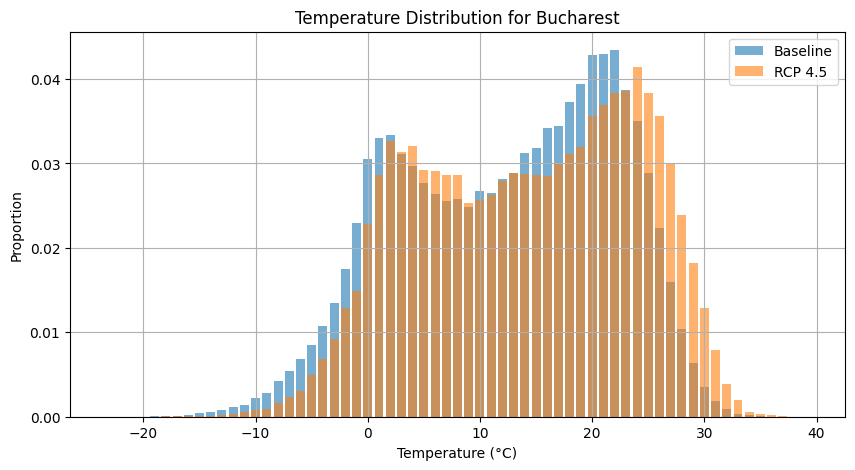

In [5]:
# Load temperature distributions
dist_baseline = pd.read_csv(BASE / f"temp_distribution_baseline_{city_name_lower}.csv")
dist_projected = pd.read_csv(BASE / f"temp_distribution_projection_{city_name_lower}.csv")
mask_rcp = dist_projected["rcp"] == f"RCP{rcp_str}"
dist_projected = dist_projected[mask_rcp].drop(columns=["rcp"])
# Ensure baseline and projected use the same "temp_bin"
dist_temp = dist_baseline.merge(dist_projected, on="temp_bin", how="outer")
dist_temp = dist_temp.fillna(0).sort_values("temp_bin")
# Rename n_days and proportion to _baseline
dist_temp = dist_temp.rename(columns={"n_days": "n_days_baseline", "proportion": "proportion_baseline"})

# Take a sample of the projected temperatures
dist_2050 = dist_temp[["temp_bin"]].copy()
dist_2050["n_days"] = dist_temp.loc[:, "n_days_2050":"n_days_2059"].sum(axis=1)
dist_2050["proportion"] = dist_2050["n_days"] / dist_2050["n_days"].sum()

# Plot them
plt.figure(figsize=(10, 5))
plt.bar(dist_temp["temp_bin"], dist_temp["proportion_baseline"], label="Baseline", alpha=0.6)
plt.bar(dist_2050["temp_bin"], dist_2050["proportion"], label=f"RCP {rcp}", alpha=0.6)
plt.ylabel("Proportion")
plt.xlabel("Temperature (°C)")
plt.title(f"Temperature Distribution for {city_name}")
plt.legend()
plt.grid()
plt.show()
plt.close()


To translate temperature exposure into mortality effects, we use
**exposure–response functions (ERFs)** estimated from epidemiological data.

Operationally, these RR curves are stored as spline coefficients:
$$
\log RR_x(T) = B(T)\beta_x
$$
where:
- $B(T)$ is the spline basis evaluated at temperature $T$,
- $\beta_x = (b_1,\dots,b_K)$ are age-group-specific coefficients.

In this step we:

1. Load all RR coefficients for the selected city.
2. Filter by `URAU_CODE` to ensure we are using the correct urban area.
3. Confirm how many age groups are available.

Each row corresponds to one **age group**, and the columns `b1, b2, ..., bK`
parameterize the log-relative-risk curve for that group.

In [6]:
# Load the coefficients for the RR calculation
coefs_all = pd.read_csv(BASE / f"coefs_{city_name_lower}.csv")

# Filter for the chosen city
coefs_city = coefs_all.loc[coefs_all["URAU_CODE"] == city_code].copy()

print(f"  Loaded coefficients for {len(coefs_city)} age groups")
display(coefs_city)  # in Colab this renders nicely

  Loaded coefficients for 81 age groups


,URAU_CODE,agegroup,b1,b2,b3,b4,b5
0,RO001C,20,0.282823,0.169493,0.083105,0.154552,0.727091
1,RO001C,21,0.282823,0.169493,0.083105,0.154552,0.727091
2,RO001C,22,0.282823,0.169493,0.083105,0.154552,0.727091
3,RO001C,23,0.282823,0.169493,0.083105,0.154552,0.727091
4,RO001C,24,0.282823,0.169493,0.083105,0.154552,0.727091
...,...,...,...,...,...,...,...
76,RO001C,96,-0.265310,-0.374636,-0.571361,-0.521178,0.413126
77,RO001C,97,-0.265310,-0.374636,-0.571361,-0.521178,0.413126
78,RO001C,98,-0.265310,-0.374636,-0.571361,-0.521178,0.413126
79,RO001C,99,-0.265310,-0.374636,-0.571361,-0.521178,0.413126


RR curves are evaluated through a spline basis $B(T)$.  
To ensure the basis is **well-aligned with the temperatures actually observed for the city**, we define:

- **Bounds** $[T_{\min}, T_{\max}]$ from the baseline daily temperature range.
- **Knots** from baseline temperature percentiles (here: 10th, 75th, 90th).

Why use the **baseline** distribution?

- The epidemiological RR curves were estimated on historical data, so a baseline-driven basis is a stable choice.
- Using the same basis consistently across years and scenarios avoids artifacts when comparing multipliers.

Implementation detail:

The baseline CSV is binned, so we reconstruct an “expanded” daily vector by repeating each `temp_bin` by its observed `n_days`.  
We then compute percentiles on this expanded vector to obtain knot locations.

This prepares the basis that will be used to transform spline coefficients `(b1..bK)` into RR values over a temperature grid.

In [7]:
# compute_mortality_multiplier_by_age — Step 4 (Python / Colab)

# Define basis-function parameters from baseline temperature distribution (CSV)
print("Defining basis function parameters from baseline temperature distribution...")

# Use the expanded baseline temperature vector (constructed from the binned CSV)
baseline_temps = dist_baseline["temp_bin"].to_numpy()
hist_temps = np.repeat(
    dist_baseline["temp_bin"].to_numpy(),
    dist_baseline["n_days"].astype(int).to_numpy()
).astype(float)

# Knots and bounds
varper = (10, 75, 90)
varknots = np.percentile(hist_temps, varper)
tmin, tmax = float(hist_temps.min()), float(hist_temps.max())

print(f"  Baseline temperature range: {tmin:.1f}°C to {tmax:.1f}°C")
print(
    f"  Knots at percentiles ({', '.join(map(str, varper))}): "
    f"{varknots[0]:.1f}, {varknots[1]:.1f}, {varknots[2]:.1f}°C"
)


Defining basis function parameters from baseline temperature distribution...
  Baseline temperature range: -23.0°C to 37.0°C
  Knots at percentiles (10, 75, 90): 0.0, 21.0, 24.0°C


Now that we have:

- baseline + projected **temperature histograms** $H_t(T)$, and
- spline **RR coefficients** $\beta$ by age group,

we can *evaluate* the exposure–response functions on the same temperature grid and overlay them on the histogram.

### Build the spline basis $B(T)$

We implement a Python equivalent of `dlnm::onebasis()` for a B-spline basis:

$$
\log RR(T) = B(T)\beta
$$

- Knots and bounds come from the **baseline** temperature distribution (previous step).
- We evaluate the basis on `temp_seq` (the temperature bins used in the histogram).
- We verify that the number of basis columns matches the available coefficient columns (`b1..bK`).

In [8]:
def build_onebasis(x: np.ndarray, knots: tuple, bound: tuple, degree:int = 2) -> np.ndarray:
    """
    Python equivalent of dlnm::onebasis(x, argvar) for varfun == "bs"
    (i.e., R splines::bs) with:
      - degree
      - internal knots = (q10, q75, q90)
      - boundary knots = (lower, upper)

    Returns
    -------
    basis : np.ndarray
        Shape (len(x), n_basis). For degree=2 and 3 knots, n_basis=5 (b1..b5).
    """
    x = np.asarray(x, dtype=float).reshape(-1)
    fun = "bs"
    lower, upper = bound
    lower, upper = float(lower), float(upper)

    # "- 1" removes the implicit intercept column that patsy would otherwise add
    formula = (
        "bs(x, knots=knots, degree=degree, "
        "include_intercept=False, lower_bound=lower, upper_bound=upper) - 1"
    )

    # Clip x to not go beyond limits
    x = np.clip(x, lower, upper)

    B = dmatrix(
        formula,
        {"x": x, "knots": knots, "degree": degree, "lower": lower, "upper": upper},
        return_type="dataframe",
    )
    basis = np.asarray(B, dtype=float)

    return basis

### Center each curve at the Minimum Mortality Temperature (MMT)

Epidemiological ERFs are anchored at a reference temperature $T^*$ where $RR(T^*)=1$.
In practice, we estimate $T^*$ as the temperature that **minimizes** the fitted log-risk over the well-populated central range of temperatures.

For each age group:

1. Compute $\log RR(T) = B(T)\beta$
2. Find the MMT $T^*$ as the minimizer of $\log RR(T)$
3. Center:
$$
\log RR_{\text{centered}}(T) = \log RR(T) - \log RR(T^*)
\quad\Rightarrow\quad
RR_{\text{centered}}(T)=\exp(\log RR_{\text{centered}}(T))
$$
This guarantees $RR(T^*) = 1$.

### Plot: histogram + RR curves (dual axis)

We plot:

- **Histogram(s)** on the left axis (proportion of days by temperature bin),
- **RR curves** for selected ages on the right axis.

This visualization is important because it shows *where* the city spends most of its days (histogram mass) and *how risky* those temperatures are (RR height).  
In later steps, this becomes the annual mean RR:
$$
\overline{RR}_{x,t}=\sum_T H_t(T)\,RR_x(T)
$$

**Implementation notes**
- We clip temperatures to spline bounds for stable basis evaluation.
- We apply linear interpolation/extrapolation defensively (mostly for robustness).
- We enforce \(RR \ge 1\) to avoid spline artifacts in poorly-informed tails.

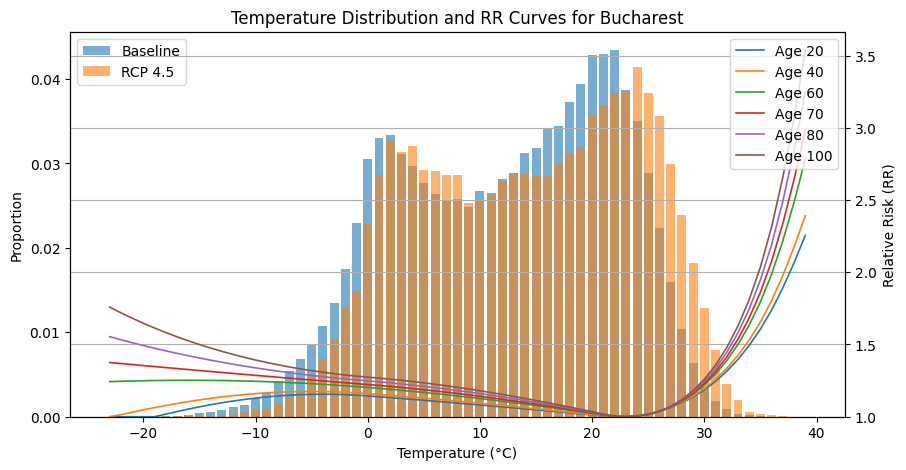

In [9]:
# --- Plot temperature histograms + RR curves (Masselot-style tail extrapolation) ---

ls_ages = [20, 40, 60, 70, 80, 100]

# Temperature bins used in the histograms (can include values outside baseline range)
temp_seq = dist_temp["temp_bin"].to_numpy(dtype=float)

# Bounds/knots from baseline (already computed earlier: tmin, tmax, varknots)
varbound = (float(tmin), float(tmax))

# Ensure coefficient columns ordered b1..bK
coef_cols = sorted([c for c in coefs_city.columns if c.startswith("b")],
                   key=lambda s: int(s[1:]))

# ---- Helper: Masselot-style tail handling = linear in log(RR) beyond historical range ----
def rr_with_loglin_extrap(temp_eval, temp_grid_in, rr_grid_in, tmin, tmax):
    """
    Masselot et al. tail behavior:
      - interpolate within historical range in log(RR)
      - extrapolate linearly in log(RR) outside [tmin, tmax]
      - enforce RR >= 1
    """
    temp_eval = np.asarray(temp_eval, dtype=float)

    # Sort in-range grid
    order = np.argsort(temp_grid_in)
    t = np.asarray(temp_grid_in, dtype=float)[order]
    rr = np.asarray(rr_grid_in, dtype=float)[order]

    # Safety
    rr = np.maximum(rr, 1e-12)  # avoid log(0)
    logrr = np.log(rr)

    if len(t) < 2:
        out = np.exp(np.interp(temp_eval, t, logrr))
        return np.maximum(out, 1.0)

    # Slopes in log space (log-linear tails)
    left_slope = (logrr[1] - logrr[0]) / (t[1] - t[0])
    right_slope = (logrr[-1] - logrr[-2]) / (t[-1] - t[-2])

    # Interpolate in-range in log space
    out_logrr = np.interp(temp_eval, t, logrr)

    # Extrapolate in log space
    left = temp_eval < tmin
    right = temp_eval > tmax
    out_logrr[left] = logrr[0] + left_slope * (temp_eval[left] - t[0])
    out_logrr[right] = logrr[-1] + right_slope * (temp_eval[right] - t[-1])

    out = np.exp(out_logrr)
    return np.maximum(out, 1.0)  # constrain RR >= 1 (as in Masselot)


# ---- Evaluate spline only on an in-range grid (avoid clipping artifacts) ----
temp_grid = np.linspace(tmin, tmax, 400)  # dense, strictly within bounds
basis_grid = build_onebasis(temp_grid, knots=varknots, bound=varbound)

# Central region for stable MMT search (avoid noisy tails)
q25, q99 = np.quantile(temp_grid, [0.25, 0.99])
ind = (temp_grid >= q25) & (temp_grid <= q99)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(10, 5))
ax2 = ax.twinx()

# Temperature histograms (left axis)
ax.bar(dist_temp["temp_bin"], dist_temp["proportion_baseline"], label="Baseline", alpha=0.6)
ax.bar(dist_2050["temp_bin"], dist_2050["proportion"], label=f"RCP {rcp}", alpha=0.6)
ax.set_ylabel("Proportion")
ax.set_xlabel("Temperature (°C)")

# RR curves (right axis)
for age in ls_ages:
    grp = coefs_city.loc[coefs_city["agegroup"] == age]
    if grp.empty:
        raise ValueError(f"Missing coefficients for agegroup={age}")

    row = grp.iloc[0]
    coefs = row[coef_cols].to_numpy(dtype=float)

    # Log RR on the in-range grid
    log_rr_grid = basis_grid @ coefs

    # MMT = argmin(log RR) in central range
    mmt = temp_grid[ind][np.argmin(log_rr_grid[ind])]

    # Centering: RR(mmt)=1
    cen_basis = build_onebasis(np.array([mmt]), knots=varknots, bound=varbound)
    center = float((cen_basis @ coefs).item())

    rr_grid = np.exp(log_rr_grid - center)
    rr_grid = np.maximum(rr_grid, 1.0)

    # Evaluate at histogram bins with Masselot-style log-linear extrapolation
    rr_plot = rr_with_loglin_extrap(temp_seq, temp_grid, rr_grid, tmin, tmax)

    ax2.plot(temp_seq, rr_plot, linewidth=1.2, alpha=1.0, label=f"Age {age}")

ax2.set_ylabel("Relative Risk (RR)")
ax2.set_ylim(bottom=1.0)

ax.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.title(f"Temperature Distribution and RR Curves for {city_name}")
plt.grid()
plt.show()
plt.close()

---

## 3. Mortality Multiplier

We now move from "a curve on a plot" to the core quantity used in the mortality adjustment:

$$
\overline{RR}_{x,t}=\sum_T H_t(T)\,RR_x(T)
$$

This step produces a full matrix of **annual mean relative risks** across:
- single-year ages $x = 20,\dots,100$
- projection years $t = 2019,\dots,2099$

### What the code does

1. **Build a fine temperature grid** (0.1°C resolution) and evaluate the spline basis on it.  
   This gives smooth RR curves and stable MMT centering.

2. **Compute an RR curve per age** using the age-specific spline coefficients:
   $$
   \log RR_x(T)=B(T)\beta_x
   $$

3. **Center at the MMT** (minimizer of $\log RR_x$ over the central temperature range), ensuring $RR=1$ at the reference temperature.

4. **Map RR values to the histogram bins** so we can weight by `n_days` efficiently.

5. **Compute annual mean RR** for:
   - the **baseline** distribution (stored under key `0` as the historical reference mean RR), and
   - each future year $t\$ using the projected `n_days_t` column.

The result is `rr_table`, where each entry approximates $\overline{RR}_{x,t}$.  
This is the input for the **normalized mortality multiplier** in the next step:
$$
\widetilde{M}_{x,t}=
\frac{\overline{RR}_{x,t}}{\text{baseline mean of }\overline{RR}_{x,\cdot}}
$$

**Sanity check:** for fixed $x$, $\overline{RR}_{x,t}$ should rise in later years under higher RCPs (especially at older ages), reflecting increased exposure to high-risk heat days.

In [10]:
ls_ages = np.arange(20, 101)
ls_years = np.arange(2019, 2100)

# Ensure coefficient columns ordered b1..bK
coef_cols = sorted([c for c in coefs_city.columns if c.startswith("b")],
                   key=lambda s: int(s[1:]))

# In-range temperature grid for spline evaluation (historical bounds)
grid_step = 0.1
temp_grid = np.arange(tmin, tmax + 1e-9, grid_step)
basis_grid = build_onebasis(temp_grid, knots=varknots, bound=(tmin, tmax))

# Central range for stable MMT search
q25, q99 = np.quantile(temp_grid, [0.25, 0.99])
ind = (temp_grid >= q25) & (temp_grid <= q99)

# Histogram bins we need RR at (may include out-of-range temps)
temp_bins = dist_temp["temp_bin"].to_numpy(dtype=float)

# Baseline days (weights)
n_days_base = dist_temp["n_days_baseline"].to_numpy(dtype=float)
n_days_base_sum = n_days_base.sum()
if n_days_base_sum <= 0:
    raise ValueError("Baseline n_days sum is zero; check dist_temp construction.")

def rr_at_temps_masselot(temp_eval, temp_grid_in, rr_grid_in, tmin, tmax):
    """
    Return RR(temp_eval) with Masselot-style tail extrapolation:
      - interpolate within range in log(RR)
      - extrapolate linearly in log(RR) beyond [tmin, tmax]
      - enforce RR >= 1
    """
    temp_eval = np.asarray(temp_eval, dtype=float)

    # sort in-range grid
    order = np.argsort(temp_grid_in)
    t = np.asarray(temp_grid_in, dtype=float)[order]
    rr = np.asarray(rr_grid_in, dtype=float)[order]

    rr = np.maximum(rr, 1e-12)
    logrr = np.log(rr)

    if len(t) < 2:
        out = np.exp(np.interp(temp_eval, t, logrr))
        return np.maximum(out, 1.0)

    # log-linear slopes at tails
    left_slope = (logrr[1] - logrr[0]) / (t[1] - t[0])
    right_slope = (logrr[-1] - logrr[-2]) / (t[-1] - t[-2])

    # interpolate within range in log space
    out_logrr = np.interp(temp_eval, t, logrr)

    # extrapolate in log space
    left = temp_eval < tmin
    right = temp_eval > tmax
    out_logrr[left]  = logrr[0]  + left_slope  * (temp_eval[left]  - t[0])
    out_logrr[right] = logrr[-1] + right_slope * (temp_eval[right] - t[-1])

    out = np.exp(out_logrr)
    return np.maximum(out, 1.0)

dict_rr = {}

for age in ls_ages:
    grp = coefs_city.loc[coefs_city["agegroup"] == age]
    if grp.empty:
        raise ValueError(f"Missing coefficients for age={age}")
    coefs = grp.iloc[0][coef_cols].to_numpy(dtype=float)

    # log RR on in-range grid
    log_rr = basis_grid @ coefs

    # MMT and centering (RR=1 at MMT)
    mmt = temp_grid[ind][np.argmin(log_rr[ind])]
    cen_basis = build_onebasis(np.array([mmt]), knots=varknots, bound=(tmin, tmax))
    center = float((cen_basis @ coefs).item())

    rr_grid = np.exp(log_rr - center)
    rr_grid = np.maximum(rr_grid, 1.0)

    # RR evaluated at histogram bins with Masselot tails
    rr_at_bins = rr_at_temps_masselot(temp_bins, temp_grid, rr_grid, tmin, tmax)

    # Baseline annual mean RR
    rr_avg_base = float((rr_at_bins * n_days_base).sum() / n_days_base_sum)
    dict_year = {0: rr_avg_base}

    # Future years annual mean RR
    for year in ls_years:
        col = f"n_days_{year}"
        if col not in dist_temp.columns:
            continue
        n_days_y = dist_temp[col].to_numpy(dtype=float)
        s = n_days_y.sum()
        dict_year[year] = np.nan if s <= 0 else float((rr_at_bins * n_days_y).sum() / s)

    dict_rr[age] = dict_year

rr_table = pd.DataFrame(dict_rr).sort_index()
rr_table

,20,21,22,23,24,25,26,27,28,29,...,91,92,93,94,95,96,97,98,99,100
0,1.071017,1.071017,1.071017,1.071017,1.071017,1.071017,1.071017,1.071017,1.071017,1.071017,...,1.143760,1.144976,1.145584,1.145584,1.145584,1.145584,1.145584,1.145584,1.145584,1.145584
2019,1.070668,1.070668,1.070668,1.070668,1.070668,1.070668,1.070668,1.070668,1.070668,1.070668,...,1.141704,1.142893,1.143487,1.143487,1.143487,1.143487,1.143487,1.143487,1.143487,1.143487
2020,1.071301,1.071301,1.071301,1.071301,1.071301,1.071301,1.071301,1.071301,1.071301,1.071301,...,1.142450,1.143638,1.144233,1.144233,1.144233,1.144233,1.144233,1.144233,1.144233,1.144233
2021,1.067956,1.067956,1.067956,1.067956,1.067956,1.067956,1.067956,1.067956,1.067956,1.067956,...,1.136759,1.137910,1.138486,1.138486,1.138486,1.138486,1.138486,1.138486,1.138486,1.138486
2022,1.068001,1.068001,1.068001,1.068001,1.068001,1.068001,1.068001,1.068001,1.068001,1.068001,...,1.134723,1.135837,1.136394,1.136394,1.136394,1.136394,1.136394,1.136394,1.136394,1.136394
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2095,1.078522,1.078522,1.078522,1.078522,1.078522,1.078522,1.078522,1.078522,1.078522,1.078522,...,1.146232,1.147363,1.147930,1.147930,1.147930,1.147930,1.147930,1.147930,1.147930,1.147930
2096,1.075671,1.075671,1.075671,1.075671,1.075671,1.075671,1.075671,1.075671,1.075671,1.075671,...,1.141032,1.142123,1.142669,1.142669,1.142669,1.142669,1.142669,1.142669,1.142669,1.142669
2097,1.078713,1.078713,1.078713,1.078713,1.078713,1.078713,1.078713,1.078713,1.078713,1.078713,...,1.145865,1.146988,1.147549,1.147549,1.147549,1.147549,1.147549,1.147549,1.147549,1.147549
2098,1.082268,1.082268,1.082268,1.082268,1.082268,1.082268,1.082268,1.082268,1.082268,1.082268,...,1.153085,1.154269,1.154862,1.154862,1.154862,1.154862,1.154862,1.154862,1.154862,1.154862


We now inspect how the **annual mean relative risk**
$$
\overline{RR}_{x,t}
$$
varies **by age** for selected projection years.

We plot:

- Baseline (historical reference period, shown as year `0`)
- A set of representative future years (e.g. 2030, 2050, 2075, 2099)

### How to read the plot

- The horizontal dashed line at **RR = 1** marks the historical reference level.
- Curves above 1 indicate **higher mortality risk** relative to baseline climate.
- Differences across ages show how sensitivity to temperature shifts with age.

Typical patterns:
- Younger ages: small deviations (RR close to 1).
- Older ages: stronger upward drift over time under higher RCPs.
- Later years: larger deviations, reflecting stronger climate forcing.

This figure provides a direct epidemiological view of climate impact **before actuarial translation** (i.e., before converting into mortality multipliers and EPVs).

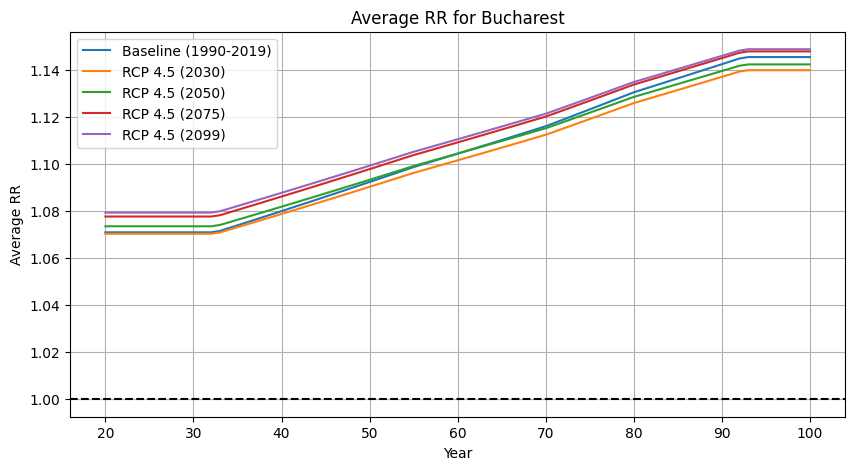

In [11]:
# Plot average for target years across the ages
ls_years = [0, 2030, 2050, 2075, 2099]
plt.figure(figsize=(10, 5))
for year in ls_years:
  if year == 0:
    label = "Baseline (1990-2019)"
  else:
    label = f"RCP {rcp} ({year})"
  plt.plot(rr_table.columns, rr_table.loc[year], label=label)

# Horizontal line across 1
plt.axhline(1, color="black", linestyle="--")
plt.xlabel("Year")
plt.ylabel("Average RR")
plt.title(f"Average RR for {city_name}")
plt.legend()
plt.grid()
plt.show()

We now transform annual mean relative risks into the **climate mortality adjustment factor**:

$$
\widetilde{M}_{x,t}
=
\frac{\overline{RR}_{x,t}}{\overline{RR}_{x,\text{baseline}}}
$$

This normalization is essential because:

- Baseline mortality $m^{\mathrm{ref}}_{x,t}$ was calibrated on historical data.
- Historical temperature effects are already embedded in those rates.
- Dividing by the historical mean RR ensures we measure **incremental climate change effects only**.

### Implementation details

For each age $x$:

1. Extract the baseline mean RR (`rr_base = rr_table.loc[0, age]`).
2. Divide the entire time series $\overline{RR}_{x,t}$ by that baseline value.
3. Store the resulting multiplier series.

We then construct `mort_table`:

- **Rows:** projection years $t$
- **Columns:** ages $x$
- **Entries:** $\widetilde{M}_{x,t}$

We drop row `0` because that corresponds to the historical baseline used for normalization (and would equal 1 by construction).

### Interpretation

- $\widetilde{M}_{x,t} > 1$: higher mortality due to temperature change.
- $\widetilde{M}_{x,t} < 1$: net mortality reduction (e.g., reduced cold exposure dominating heat).

This table is the direct input for adjusting central death rates:

$$
m^{\mathrm{clim}}_{x,t}
=
m^{\mathrm{ref}}_{x,t} \times \widetilde{M}_{x,t}.
$$

In [12]:
# Build a dictionary to store the mortality multipliers
# per age and year
dict_mort = {}
ls_ages = np.arange(20, 101)

for age in ls_ages:
  rr_base = rr_table.loc[0, age]
  mort_multi = rr_table.loc[:, age] / rr_base
  dict_mort[age] = mort_multi

# Build table. age is rows and year is columns
mort_table = pd.DataFrame(dict_mort)
# Drop row 0
mort_table = mort_table.drop(0)
mort_table

,20,21,22,23,24,25,26,27,28,29,...,91,92,93,94,95,96,97,98,99,100
2019,0.999675,0.999675,0.999675,0.999675,0.999675,0.999675,0.999675,0.999675,0.999675,0.999675,...,0.998202,0.998181,0.998170,0.998170,0.998170,0.998170,0.998170,0.998170,0.998170,0.998170
2020,1.000266,1.000266,1.000266,1.000266,1.000266,1.000266,1.000266,1.000266,1.000266,1.000266,...,0.998854,0.998832,0.998821,0.998821,0.998821,0.998821,0.998821,0.998821,0.998821,0.998821
2021,0.997142,0.997142,0.997142,0.997142,0.997142,0.997142,0.997142,0.997142,0.997142,0.997142,...,0.993879,0.993829,0.993804,0.993804,0.993804,0.993804,0.993804,0.993804,0.993804,0.993804
2022,0.997184,0.997184,0.997184,0.997184,0.997184,0.997184,0.997184,0.997184,0.997184,0.997184,...,0.992099,0.992018,0.991978,0.991978,0.991978,0.991978,0.991978,0.991978,0.991978,0.991978
2023,0.998897,0.998897,0.998897,0.998897,0.998897,0.998897,0.998897,0.998897,0.998897,0.998897,...,0.995818,0.995770,0.995746,0.995746,0.995746,0.995746,0.995746,0.995746,0.995746,0.995746
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2095,1.007008,1.007008,1.007008,1.007008,1.007008,1.007008,1.007008,1.007008,1.007008,1.007008,...,1.002161,1.002085,1.002048,1.002048,1.002048,1.002048,1.002048,1.002048,1.002048,1.002048
2096,1.004346,1.004346,1.004346,1.004346,1.004346,1.004346,1.004346,1.004346,1.004346,1.004346,...,0.997615,0.997509,0.997455,0.997455,0.997455,0.997455,0.997455,0.997455,0.997455,0.997455
2097,1.007186,1.007186,1.007186,1.007186,1.007186,1.007186,1.007186,1.007186,1.007186,1.007186,...,1.001840,1.001757,1.001716,1.001716,1.001716,1.001716,1.001716,1.001716,1.001716,1.001716
2098,1.010506,1.010506,1.010506,1.010506,1.010506,1.010506,1.010506,1.010506,1.010506,1.010506,...,1.008153,1.008117,1.008099,1.008099,1.008099,1.008099,1.008099,1.008099,1.008099,1.008099


We now visualize the **climate mortality adjustment factor**
$$
\widetilde{M}_{x,t}
$$
for selected ages across projection years.

In this plot:

- The x-axis is **calendar year**.
- The y-axis is the **mortality multiplier**.
- The dashed horizontal line at 1 marks the historical reference level.

### Interpretation

- Values **above 1** indicate higher mortality relative to the historical climate.
- Values **below 1** indicate net mortality reduction (e.g. fewer cold-related deaths).
- Older ages typically exhibit stronger upward drift, reflecting greater temperature sensitivity.

This figure connects climate trajectories directly to actuarial inputs:
$$
m^{\mathrm{clim}}_{x,t}
=
m^{\mathrm{ref}}_{x,t} \times \widetilde{M}_{x,t}
$$

In the next step, we will apply this multiplier to the baseline mortality projection and compute life-contingent values (annuities and insurance).

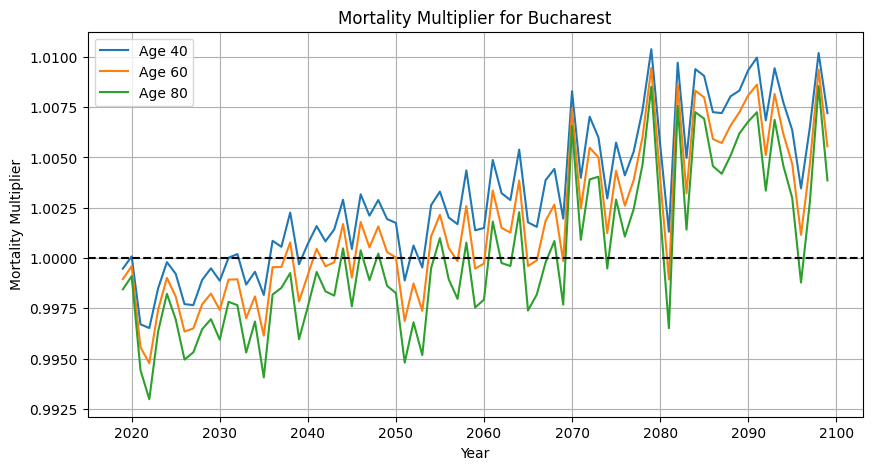

In [13]:
# Plot mortality multiplier for certain ages across the years
ls_ages = [40, 60, 80]
plt.figure(figsize=(10, 5))
for age in ls_ages:
  plt.plot(mort_table.index, mort_table[age], label=f"Age {age}")

# Horizontal line across 1
plt.axhline(1, color="black", linestyle="--")
plt.xlabel("Year")
plt.ylabel("Mortality Multiplier")
plt.title(f"Mortality Multiplier for {city_name}")
plt.legend()
plt.grid()
plt.show()

---

## 4. Mortality Projections

Up to now, we have built **climate multipliers** $\widetilde{M}_{x,t}$ from temperature and epidemiology.
Next we need a **baseline actuarial mortality surface** to adjust.

In this demo we use **Eurostat EUROPOP-style projections** as the reference mortality basis, providing (by age and year):

- $m^{\mathrm{ref}}_{x,t}$: central death rate (`mx`)
- $q^{\mathrm{ref}}_{x,t}$: one-year death probability (`qx`)
- $a_x$: fraction-of-year lived by those dying (`ax`) used in the $m \to q$ relationship

### What this cell does

1. Loads the projected mortality dataset for the selected city.
2. Filters to ages **20+** (consistent with our cohort/EPV examples).
3. Sorts by `(year, age)` to support cohort-style access later.
4. Validates that the cohort starting point $(x,t)=(20,2019)$ exists.
5. Extracts a **reference period life table slice** for the cohort start year (2019):
   - `baseline_lt[age] = (qx, mx, ax)`

### Why we take a baseline slice

- The full dataset is needed for **cohort calculations** (following the diagonal $(x+k, t+k)$).
- A single-year slice is still useful for:
  - sanity checks,
  - period-life-table illustrations,
  - validating the `mx → qx` consistency.

In the next step, we will apply the multiplier to obtain climate-adjusted rates:
$$
m^{\mathrm{clim}}_{x,t} = m^{\mathrm{ref}}_{x,t}\,\widetilde{M}_{x,t}
\quad\Rightarrow\quad
q^{\mathrm{clim}}_{x,t}=\frac{m^{\mathrm{clim}}_{x,t}}{1+(1-a_x)m^{\mathrm{clim}}_{x,t}}.
$$

In [14]:
print("Loading Eurostat projected mortality data...\n")

cohort_start_age = 20
cohort_start_year = 2019
cohort_end_year = 2099

# Load projections
mort_proj = pd.read_csv(BASE / f"{city_name_lower}_mortality_projections.csv")

# Filter ages 20+
mort_proj = mort_proj[mort_proj["age"] >= 20].copy()

# Sort like setkey(year, age)
mort_proj = mort_proj.sort_values(["year", "age"])

print(f"  Loaded Eurostat projections: {len(mort_proj)} records")
print(f"  Age range: {mort_proj['age'].min()} to {mort_proj['age'].max()}")
print(f"  Year range: {mort_proj['year'].min()} to {mort_proj['year'].max()}")

# Verify cohort coverage
cohort_check = mort_proj[
    (mort_proj["year"] == cohort_start_year) &
    (mort_proj["age"] == cohort_start_age)
]

if cohort_check.empty:
    raise ValueError(
        f"Missing {cohort_start_year} data for age {cohort_start_age} in mortality projections!"
    )

print(
    f"  Cohort start qx (age {cohort_start_age}, {cohort_start_year}): "
    f"{cohort_check['qx'].iloc[0]:.6f}"
)

# Baseline lookup table (year = cohort_start_year)
mask_start = mort_proj["year"] == cohort_start_year
baseline_lt = mort_proj[mask_start][["age", "qx", "mx", "ax"]].copy()

baseline_lt = baseline_lt.sort_values("age").set_index("age")

Loading Eurostat projected mortality data...

  Loaded Eurostat projections: 6642 records
  Age range: 20 to 100
  Year range: 2019 to 2100
  Cohort start qx (age 20, 2019): 0.000277


We now prepare the climate mortality adjustment factors for integration with the baseline mortality projection.

Currently:

- `mort_table`
  - **Rows:** years $t$
  - **Columns:** ages $x$
  - **Values:** $\widetilde{M}_{x,t}$

For merging with the Eurostat projection (which is already in long format `(year, age)`), we convert the multipliers into a **long dataframe**:

$$
(year,\, age,\, multiplier)
$$

### What this step ensures

1. The index is explicitly labeled as `year` and cast to integer.
2. We reshape using `melt()` so each row corresponds to a unique `(year, age)` pair.
3. We restrict to the cohort window:
   - years between `cohort_start_year` and `cohort_end_year`
   - ages $\geq$ `cohort_start_age`
4. We attach scenario labels (`rcp`, `ssp`) for traceability.
5. We verify that the cohort starting point has a valid multiplier.

### Why this matters

This structure allows a clean merge:

$$
m^{\mathrm{clim}}_{x,t}
=
m^{\mathrm{ref}}_{x,t} \times \widetilde{M}_{x,t}
$$

Once merged, each mortality record will carry both:

- baseline mortality (`mx`, `qx`),
- and the climate multiplier.

In the next step, we will compute climate-adjusted mortality rates and proceed to cohort EPVs.

In [15]:
# Build "multipliers" table from mort_table (already computed)

print("Building mortality multipliers table from mort_table (already computed)...\n")

# mort_table structure:
#   - index: years (e.g., 2019..2099)
#   - columns: ages (20..100)
#   - values: mortality multiplier (RR_year / RR_baseline) by age
#
# We convert it to a long dataframe: (year, age, multiplier)

# Ensure index is named and is an int year
mort_table.index.name = "year"
mort_table.index = mort_table.index.astype(int)

multipliers = (
    mort_table
    .reset_index()                      # year becomes a column
    .melt(id_vars="year", var_name="age", value_name="multiplier")
)

# Make sure age is int
multipliers["age"] = multipliers["age"].astype(int)

# Keep only cohort window (safety)
multipliers = multipliers[
    (multipliers["year"] >= cohort_start_year) &
    (multipliers["year"] <= cohort_end_year) &
    (multipliers["age"] >= cohort_start_age)
].copy()

# Add scenario labels (single scenario notebook)
multipliers["rcp"] = rcp
multipliers["ssp"] = ssp_val

# Sort like setkey(ssp, year, age)
multipliers = multipliers.sort_values(["ssp", "year", "age"]).reset_index(drop=True)

print(f"  Built multipliers: {len(multipliers):,} rows")
print("  Years:", multipliers["year"].min(), "to", multipliers["year"].max())
print("  Ages :", multipliers["age"].min(), "to", multipliers["age"].max())

# Quick coverage check for cohort start
chk = multipliers[(multipliers["year"] == cohort_start_year) & (multipliers["age"] == cohort_start_age)]
if chk.empty:
    raise ValueError(f"Missing multiplier for cohort start: year={cohort_start_year}, age={cohort_start_age}")

print(
    f"  Multiplier at cohort start (age {cohort_start_age}, {cohort_start_year}): "
    f"{chk['multiplier'].iloc[0]:.6f}"
)

Building mortality multipliers table from mort_table (already computed)...

  Built multipliers: 6,561 rows
  Years: 2019 to 2099
  Ages : 20 to 100
  Multiplier at cohort start (age 20, 2019): 0.999675


We now combine the two main ingredients:

- **Baseline projected mortality** from Eurostat: $m^{\mathrm{ref}}_{x,t}$, $q^{\mathrm{ref}}_{x,t}$
- **Climate mortality multipliers**: $\widetilde{M}_{x,t}$

to construct a **cohort life table**, which follows a single birth cohort as it ages through calendar time.

### Why a cohort table?

A **period** life table holds a single year $t$ fixed and applies $\{q_{x,t}\}$ to a synthetic cohort.

A **cohort** life table follows the diagonal:
$$
(x,t), (x+1,t+1), (x+2,t+2), \dots
$$
which is exactly what we need for product valuation and reserves, since real contracts experience improving mortality and evolving climate over time.

### Convert rates to probabilities (if needed)

We use the standard actuarial approximation:
$$
q_{x,t} = \frac{m_{x,t}}{1 + (1-a_x)m_{x,t}}
$$
implemented as `mx_to_qx()`.

This ensures consistency when we adjust $m$ and need the corresponding $q$.

### Merge baseline mortality and climate multipliers along the cohort path

For a cohort starting at:
- age `cohort_start_age` in year `cohort_start_year`

we build a table with one row per future year, where the cohort age increments by one each year.

Then we merge:
- baseline `mx_base`, `qx_base`, `ax` from Eurostat projections
- `multiplier` from the climate adjustment output

Any missing multipliers default to **1.0** (no climate adjustment available).

### Compute climate-adjusted mortality and cohort survivorship

Climate-adjusted central death rate:
$$
m^{\mathrm{clim}}_{x,t} = m^{\mathrm{ref}}_{x,t}\,\widetilde{M}_{x,t}
$$

Climate-adjusted death probability:
$$
q^{\mathrm{clim}}_{x,t} =
\frac{m^{\mathrm{clim}}_{x,t}}{1 + (1-a_x)m^{\mathrm{clim}}_{x,t}}
$$

Finally, starting from a radix $l_0=100{,}000$, we compute cohort survivorship recursively:

$$
\ell_{k+1} = \ell_k\,(1-q_k),\qquad d_k=\ell_k\,q_k
$$

We compute these quantities under both bases:
- **baseline** (`lx_base`, `dx_base`)
- **climate-adjusted** (`lx_clim`, `dx_clim`)

This cohort table `lt` is the foundation for EPVs of annuities and life insurance in the next step.

In [16]:
# Build Cohort Life Table (single SSP/RCP)

print("Building cohort life table...\n")

# --- Helper: mx -> qx (standard life table approximation) ---
def mx_to_qx(mx, ax):
    """
    Convert central death rate mx to death probability qx using:
      qx = mx / (1 + (1-ax)*mx)
    Works elementwise for numpy arrays / pandas Series.
    """
    mx = np.asarray(mx, dtype=float)
    ax = np.asarray(ax, dtype=float)
    qx = mx / (1.0 + (1.0 - ax) * mx)
    qx = np.clip(qx, 0.0, 1.0)
    return qx


def build_cohort_lifetable_single(mort_proj_df: pd.DataFrame,
                                  multipliers_df: pd.DataFrame,
                                  radix: float = 100000) -> pd.DataFrame:
    """
    Build cohort life table with year-specific Eurostat mortality (qx/mx improving over time)
    and climate multipliers (already computed for each year/age).

    Assumes single SSP/RCP and single adaptation ("none").
    """

    # Cohort ages: age 20 in start year, age 21 next year, ... until end year
    cohort_years = np.arange(cohort_start_year, cohort_end_year + 1, dtype=int)
    cohort_ages  = cohort_start_age + (cohort_years - cohort_start_year)

    lt = pd.DataFrame({
        "year": cohort_years,
        "age":  cohort_ages,
        "rcp":  rcp,
        "ssp":  ssp_val,
    })

    # --- Merge YEAR-SPECIFIC baseline mortality from Eurostat projections ---
    base_cols = ["year", "age", "qx", "mx", "ax"]
    base = mort_proj_df[base_cols].copy().rename(columns={
        "qx": "qx_base",
        "mx": "mx_base",
    })

    lt = lt.merge(base, on=["year", "age"], how="left")

    # Fill any missing baseline mortality using last available year per age (fallback)
    if lt["qx_base"].isna().any():
        max_year = mort_proj_df["year"].max()
        fallback = mort_proj_df[mort_proj_df["year"] == max_year][["age", "qx", "mx", "ax"]].copy()
        fallback = fallback.rename(columns={"qx": "qx_f", "mx": "mx_f", "ax": "ax_f"})

        lt = lt.merge(fallback, on="age", how="left")
        lt["qx_base"] = lt["qx_base"].fillna(lt["qx_f"])
        lt["mx_base"] = lt["mx_base"].fillna(lt["mx_f"])
        lt["ax"]      = lt["ax"].fillna(lt["ax_f"])
        lt = lt.drop(columns=[c for c in ["qx_f", "mx_f", "ax_f"] if c in lt.columns])

    # Final safety defaults
    lt["ax"] = lt["ax"].fillna(0.5)

    # Hard check: still missing mortality?
    if lt["qx_base"].isna().any() or lt["mx_base"].isna().any():
        missing = lt[lt["qx_base"].isna() | lt["mx_base"].isna()][["year", "age"]]
        raise ValueError(f"Missing baseline mortality for {len(missing)} cohort year-age rows.")

    # Cap baseline qx at 1
    lt["qx_base"] = lt["qx_base"].clip(upper=1.0)

    # --- Merge climate multipliers (already computed) ---
    # multipliers_df has columns: year, age, multiplier, ssp, adaptation, rcp (from step 11 fix)
    mult = multipliers_df[["year", "age", "multiplier"]].copy()
    lt = lt.merge(mult, on=["year", "age"], how="left")

    # Fill missing multipliers with 1 (no climate data for that year/age)
    lt["multiplier"] = lt["multiplier"].fillna(1.0)

    # --- Climate-adjusted mx and qx ---
    lt["mx_clim"] = lt["mx_base"] * lt["multiplier"]
    lt["qx_clim"] = mx_to_qx(lt["mx_clim"].values, lt["ax"].values)
    lt["qx_clim"] = np.minimum(lt["qx_clim"], 1.0)

    # --- Compute lx, dx for baseline and climate ---
    # Cohort is already ordered by year/age progression
    lt = lt.sort_values(["year", "age"]).reset_index(drop=True)

    lx_base = np.empty(len(lt), dtype=float)
    lx_clim = np.empty(len(lt), dtype=float)
    lx_base[0] = radix
    lx_clim[0] = radix

    for i in range(1, len(lt)):
        lx_base[i] = lx_base[i-1] * (1.0 - lt.loc[i-1, "qx_base"])
        lx_clim[i] = lx_clim[i-1] * (1.0 - lt.loc[i-1, "qx_clim"])

    lt["lx_base"] = lx_base
    lt["dx_base"] = lt["lx_base"] * lt["qx_base"]
    lt["lx_clim"] = lx_clim
    lt["dx_clim"] = lt["lx_clim"] * lt["qx_clim"]

    return lt


# Build single cohort life table
lt = build_cohort_lifetable_single(mort_proj, multipliers, radix=100000)

print(f"  Built cohort life table with {len(lt)} rows")
print(f"  Years: {lt['year'].min()}–{lt['year'].max()} | Ages: {lt['age'].min()}–{lt['age'].max()}")
lt

Building cohort life table...

  Built cohort life table with 81 rows
  Years: 2019–2099 | Ages: 20–100


,year,age,rcp,ssp,qx_base,mx_base,ax,multiplier,mx_clim,qx_clim,lx_base,dx_base,lx_clim,dx_clim
0,2019,20,4.5,SSP2,0.000277,0.000277,0.5,0.999675,0.000277,0.000277,100000.000000,27.711448,100000.000000,27.702432
1,2020,21,4.5,SSP2,0.000298,0.000298,0.5,1.000266,0.000298,0.000298,99972.288552,29.788795,99972.297568,29.796713
2,2021,22,4.5,SSP2,0.000319,0.000319,0.5,0.997142,0.000318,0.000318,99942.499757,31.832338,99942.500855,31.741387
3,2022,23,4.5,SSP2,0.000334,0.000334,0.5,0.997184,0.000333,0.000333,99910.667419,33.385476,99910.759467,33.291515
4,2023,24,4.5,SSP2,0.000360,0.000360,0.5,0.998897,0.000359,0.000359,99877.281943,35.933542,99877.467952,35.893995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,2095,96,4.5,SSP2,0.167453,0.182754,0.5,1.002048,0.183128,0.167767,25499.571594,4269.977294,25355.696249,4253.849844
77,2096,97,4.5,SSP2,0.190722,0.210827,0.5,0.997455,0.210291,0.190283,21229.594299,4048.957033,21101.846405,4015.325912
78,2097,98,4.5,SSP2,0.217059,0.243484,0.5,1.001716,0.243901,0.217391,17180.637266,3729.204896,17086.520493,3714.447279
79,2098,99,4.5,SSP2,0.246719,0.281437,0.5,1.008099,0.283716,0.248469,13451.432370,3318.723976,13372.073214,3322.545186


With the cohort life table in hand, we can translate mortality changes into **financial impacts**.

We compute EPVs exactly as in the report's definitions, using cohort-indexed mortality along $(x+k, t+k)$.

### Discounting

We set the annual effective interest rate $i$ as a **decimal** (e.g., 0.02 for 2%) and define:
$$
v = (1+i)^{-1}
$$

This discount factor is the key driver of EPV magnitudes: higher $i$ places more weight on near-term cash flows and compresses long-horizon climate effects.

### Cohort survival probabilities

Given the cohort sequence $q_{x+k,t+k}$, we compute:
$$
{}_k p_{x,t} = \prod_{j=0}^{k-1}(1-q_{x+j,t+j}),\qquad {}_0 p_{x,t}=1
$$
implemented as `kpx_from_qx()`.

### Products valued in the demo

**Deferred term annuity-due** (example product):  
Pays 1 at the beginning of each year *while alive*, starting after `defer` years and lasting `term` years:
$$
\text{EPV}=\sum_{k=\text{defer}}^{\text{defer}+\text{term}-1} v^k\;{}_k p_{x,t}
$$

**Whole-life insurance (assurance)** (paper definition):  
Pays 1 at the end of the year of death:
$$
A_{x,t}=\sum_{k\ge 0} v^{k+1}\;{}_k p_{x,t}\;q_{x+k,t+k}
$$

### Climate vs baseline comparison

We compute each EPV twice:
- using `qx_base` (reference mortality)
- using `qx_clim` (climate-adjusted mortality)

and report both the **absolute** and **percentage** change:
- annuity EPV typically **decreases** when mortality rises,
- insurance EPV typically **increases** when mortality rises.

The resulting `epv_summary` table is the notebook's headline financial output for the selected city/scenario/interest rate.

In [17]:
# Calculate Actuarial Quantities (EPV)

print("Calculating actuarial quantities (paper definitions)...\n")

# --- Set interest rate properly ---
# Use a decimal rate, e.g. 0.00, 0.02, 0.04 (NOT 2 or 4)
interest_rate = 0.02
v = 1.0 / (1.0 + interest_rate)

if not np.isfinite(v) or v <= 0:
    raise ValueError(f"Invalid discount factor v={v}. Check interest_rate={interest_rate}.")
print(f"  interest_rate i = {interest_rate:.4%}")
print(f"  discount factor v = {v:.8f}")

def kpx_from_qx(qx: np.ndarray) -> np.ndarray:
    """
    qx[k] corresponds to q_{x+k,t+k} along the cohort diagonal.
    Returns kpx[k] = {}_k p with kpx[0]=1.
    """
    qx = np.asarray(qx, dtype=float)
    if np.any(~np.isfinite(qx)):
        raise ValueError("Non-finite values in qx. Check your life table columns.")
    qx = np.clip(qx, 0.0, 1.0)
    px = 1.0 - qx

    n = len(qx)
    kpx = np.empty(n, dtype=float)
    kpx[0] = 1.0
    if n > 1:
        kpx[1:] = np.cumprod(px[:-1])
    return kpx

def epv_deferred_term_annuity_due(lt: pd.DataFrame, qx_col: str, v: float,
                                  defer: int = 45, term: int = 20) -> float:
    qx = np.clip(lt[qx_col].to_numpy(dtype=float), 0.0, 1.0)
    px = 1.0 - qx
    n = len(qx)

    kpx = np.empty(n, dtype=float)
    kpx[0] = 1.0
    if n > 1:
        kpx[1:] = np.cumprod(px[:-1])

    k_start = defer
    k_end = min(defer + term - 1, n - 1)
    if k_start > k_end:
        return 0.0

    k = np.arange(k_start, k_end + 1)
    return float(np.sum((v ** k) * kpx[k]))

def epv_insurance_whole_life(lt: pd.DataFrame, qx_col: str, v: float) -> float:
    """
    Paper Eq (assurance): A_{x,t} = Σ_{k>=0} v^{k+1} * {}_k p * q_{x+k,t+k}
    (truncated to lt length)
    """
    qx = lt[qx_col].to_numpy(dtype=float)
    kpx = kpx_from_qx(qx)
    k = np.arange(len(qx), dtype=int)
    return float(np.sum((v ** (k + 1)) * kpx * qx))

# --- Compute EPVs under baseline and climate-adjusted mortality ---
annuity_base   = epv_deferred_term_annuity_due(lt, "qx_base", v)
insurance_base = epv_insurance_whole_life(lt, "qx_base", v)

annuity_clim   = epv_deferred_term_annuity_due(lt, "qx_clim", v)
insurance_clim = epv_insurance_whole_life(lt, "qx_clim", v)

# --- Changes ---
delta_annuity = annuity_clim - annuity_base
delta_insurance = insurance_clim - insurance_base

pct_delta_annuity = 100.0 * delta_annuity / annuity_base if annuity_base != 0 else np.nan
pct_delta_insurance = 100.0 * delta_insurance / insurance_base if insurance_base != 0 else np.nan

epv_summary = pd.DataFrame([{
    "rcp": rcp,
    "i": interest_rate,
    "v": v,
    "annuity_base": annuity_base,
    "annuity_clim": annuity_clim,
    "pct_delta_annuity": pct_delta_annuity,
    "insurance_base": insurance_base,
    "insurance_clim": insurance_clim,
    "pct_delta_insurance": pct_delta_insurance,
}])

print(f"\nEPV Summary for {city_name} under RCP {rcp}:")
display(epv_summary.round({
    "annuity_base": 3,
    "annuity_clim": 3,
    "pct_delta_annuity": 3,
    "insurance_base": 4,
    "insurance_clim": 4,
    "pct_delta_insurance": 3,
}))

Calculating actuarial quantities (paper definitions)...

  interest_rate i = 2.0000%
  discount factor v = 0.98039216

EPV Summary for Bucharest under RCP 4.5:


,rcp,i,v,annuity_base,annuity_clim,pct_delta_annuity,insurance_base,insurance_clim,pct_delta_insurance
0,4.5,0.02,0.980392,5.679,5.678,-0.027,0.2644,0.2646,0.094
